In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# 1. Generate Synthetic Daily Sales (2 Years of data)
days = 730
t = np.arange(days)
# Trend + Weekly Seasonality + Random Noise
sales = 50 + 0.05 * t + 20 * np.sin(2 * np.pi * t / 7) + np.random.normal(0, 5, days)
df = pd.DataFrame(sales, columns=['Sales'])

# 2. Normalize the data (Crucial for RNNs)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_sales = scaler.fit_transform(df)

# 3. Create Sequences (Window of 30 days to predict the 31st)
def create_sequences(data, window):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window_size = 30
X, y = create_sequences(scaled_sales, window_size)

# 4. Split Train/Test (Last 60 days for testing)
split = len(X) - 60
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Training shape: {X_train.shape}") # (Batch, Steps, Features)

Training shape: (640, 30, 1)


In [2]:
model = models.Sequential([
    # LSTM layer handles the sequential nature of sales
    layers.LSTM(64, activation='relu', input_shape=(window_size, 1), return_sequences=False),

    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2), # Prevents overfitting to specific noise
    layers.Dense(1)      # Predicting a single sales value
])

model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 64)                16896     
                                                                 
 dense (Dense)               (None, 32)                2080      
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 dense_1 (Dense)             (None, 1)                 33        
                                                                 
Total params: 19,009
Trainable params: 19,009
Non-trainable params: 0
_________________________________________________________________


In [3]:
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/30
40/40 [==============================] - 1s 8ms/step - loss: 0.1780 - val_loss: 0.0752
Epoch 2/30
40/40 [==============================] - 0s 5ms/step - loss: 0.0543 - val_loss: 0.0362
Epoch 3/30
40/40 [==============================] - 0s 5ms/step - loss: 0.0429 - val_loss: 0.0515
Epoch 4/30
40/40 [==============================] - 0s 4ms/step - loss: 0.0431 - val_loss: 0.0373
Epoch 5/30
40/40 [==============================] - 0s 5ms/step - loss: 0.0420 - val_loss: 0.0387
Epoch 6/30
40/40 [==============================] - 0s 4ms/step - loss: 0.0393 - val_loss: 0.0346
Epoch 7/30
40/40 [==============================] - 0s 5ms/step - loss: 0.0417 - val_loss: 0.0445
Epoch 8/30
40/40 [==============================] - 0s 5ms/step - loss: 0.0402 - val_loss: 0.0355
Epoch 9/30
40/40 [==============================] - 0s 4ms/step - loss: 0.0417 - val_loss: 0.0338
Epoch 10/30
40/40 [==============================] - 0s 5ms/step - loss: 0.0398 - val_loss: 0.0409
Epoch 11/30
40/40 [

In [4]:
# 1. Make Predictions
predicted_scaled = model.predict(X_test)

# 2. Inverse Scale the values
predicted_sales = scaler.inverse_transform(predicted_scaled)
actual_sales = scaler.inverse_transform(y_test)

# 3. Calculate Error (Root Mean Squared Error)
rmse = np.sqrt(np.mean((predicted_sales - actual_sales)**2))
print(f"\nRoot Mean Squared Error (RMSE): ${rmse:.2f}")

2/2 [==============================] - 0s 3ms/step

Root Mean Squared Error (RMSE): $8.15


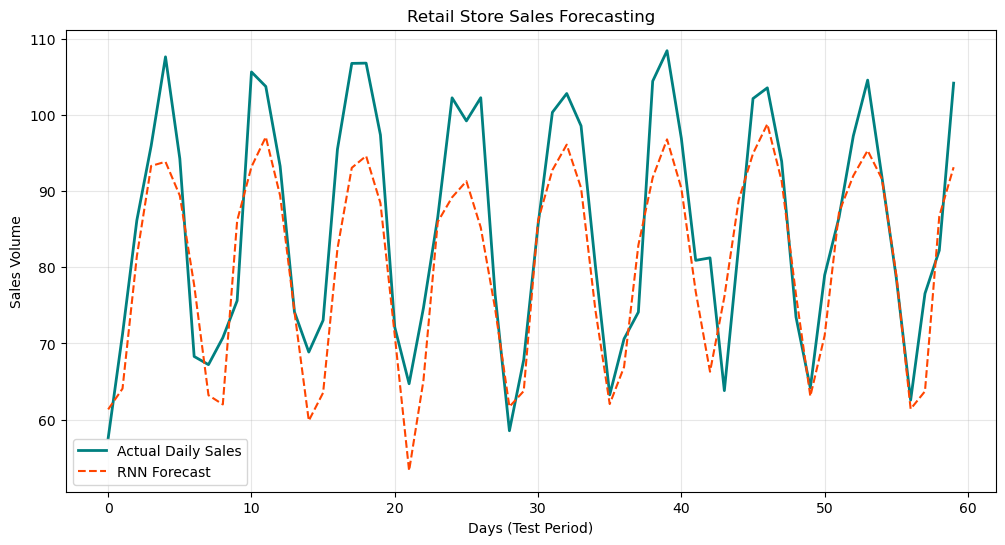

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(actual_sales, label='Actual Daily Sales', color='teal', linewidth=2)
plt.plot(predicted_sales, label='RNN Forecast', color='orangered', linestyle='--')
plt.title('Retail Store Sales Forecasting')
plt.xlabel('Days (Test Period)')
plt.ylabel('Sales Volume')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()